
📥 Downloading price data from Yahoo Finance...
   Period: 2022-01-01 → 2026-03-27

✅ Retrieved 16 tickers.
   Date range: 2022-01-04 → 2026-03-26

  FILTER 0 — COST GATE
  Threshold: OCF ≥ 0.75% → excluded | ≥ 0.50% → flagged
  ETF                                    OCF    vs VWRP   Verdict
---------------------------------------------------------------------------
  EU Defence (DEFS)                    0.35%     +0.16%   ✅ Passes
  Aero & Defence (DFND)                0.35%     +0.16%   ✅ Passes
  Defence Tech (ARMG)                  0.50%     +0.31%   ⚠️  Flagged — needs strong Filter 1+2a case
  Healthcare S&P (XLVS)                0.14%     -0.05%   ✅ Passes
  Healthcare Tech (DOCT)               0.49%     +0.30%   ✅ Passes
  Semiconductors (SMGB)                0.35%     +0.16%   ✅ Passes
  Emerging Markets (VFEG)              0.17%     -0.02%   ✅ Passes
  Tech Megatrend (ITEK)                0.59%     +0.40%   ⚠️  Flagged — needs strong Filter 1+2a case
  ARK Innovation (ARKK)  

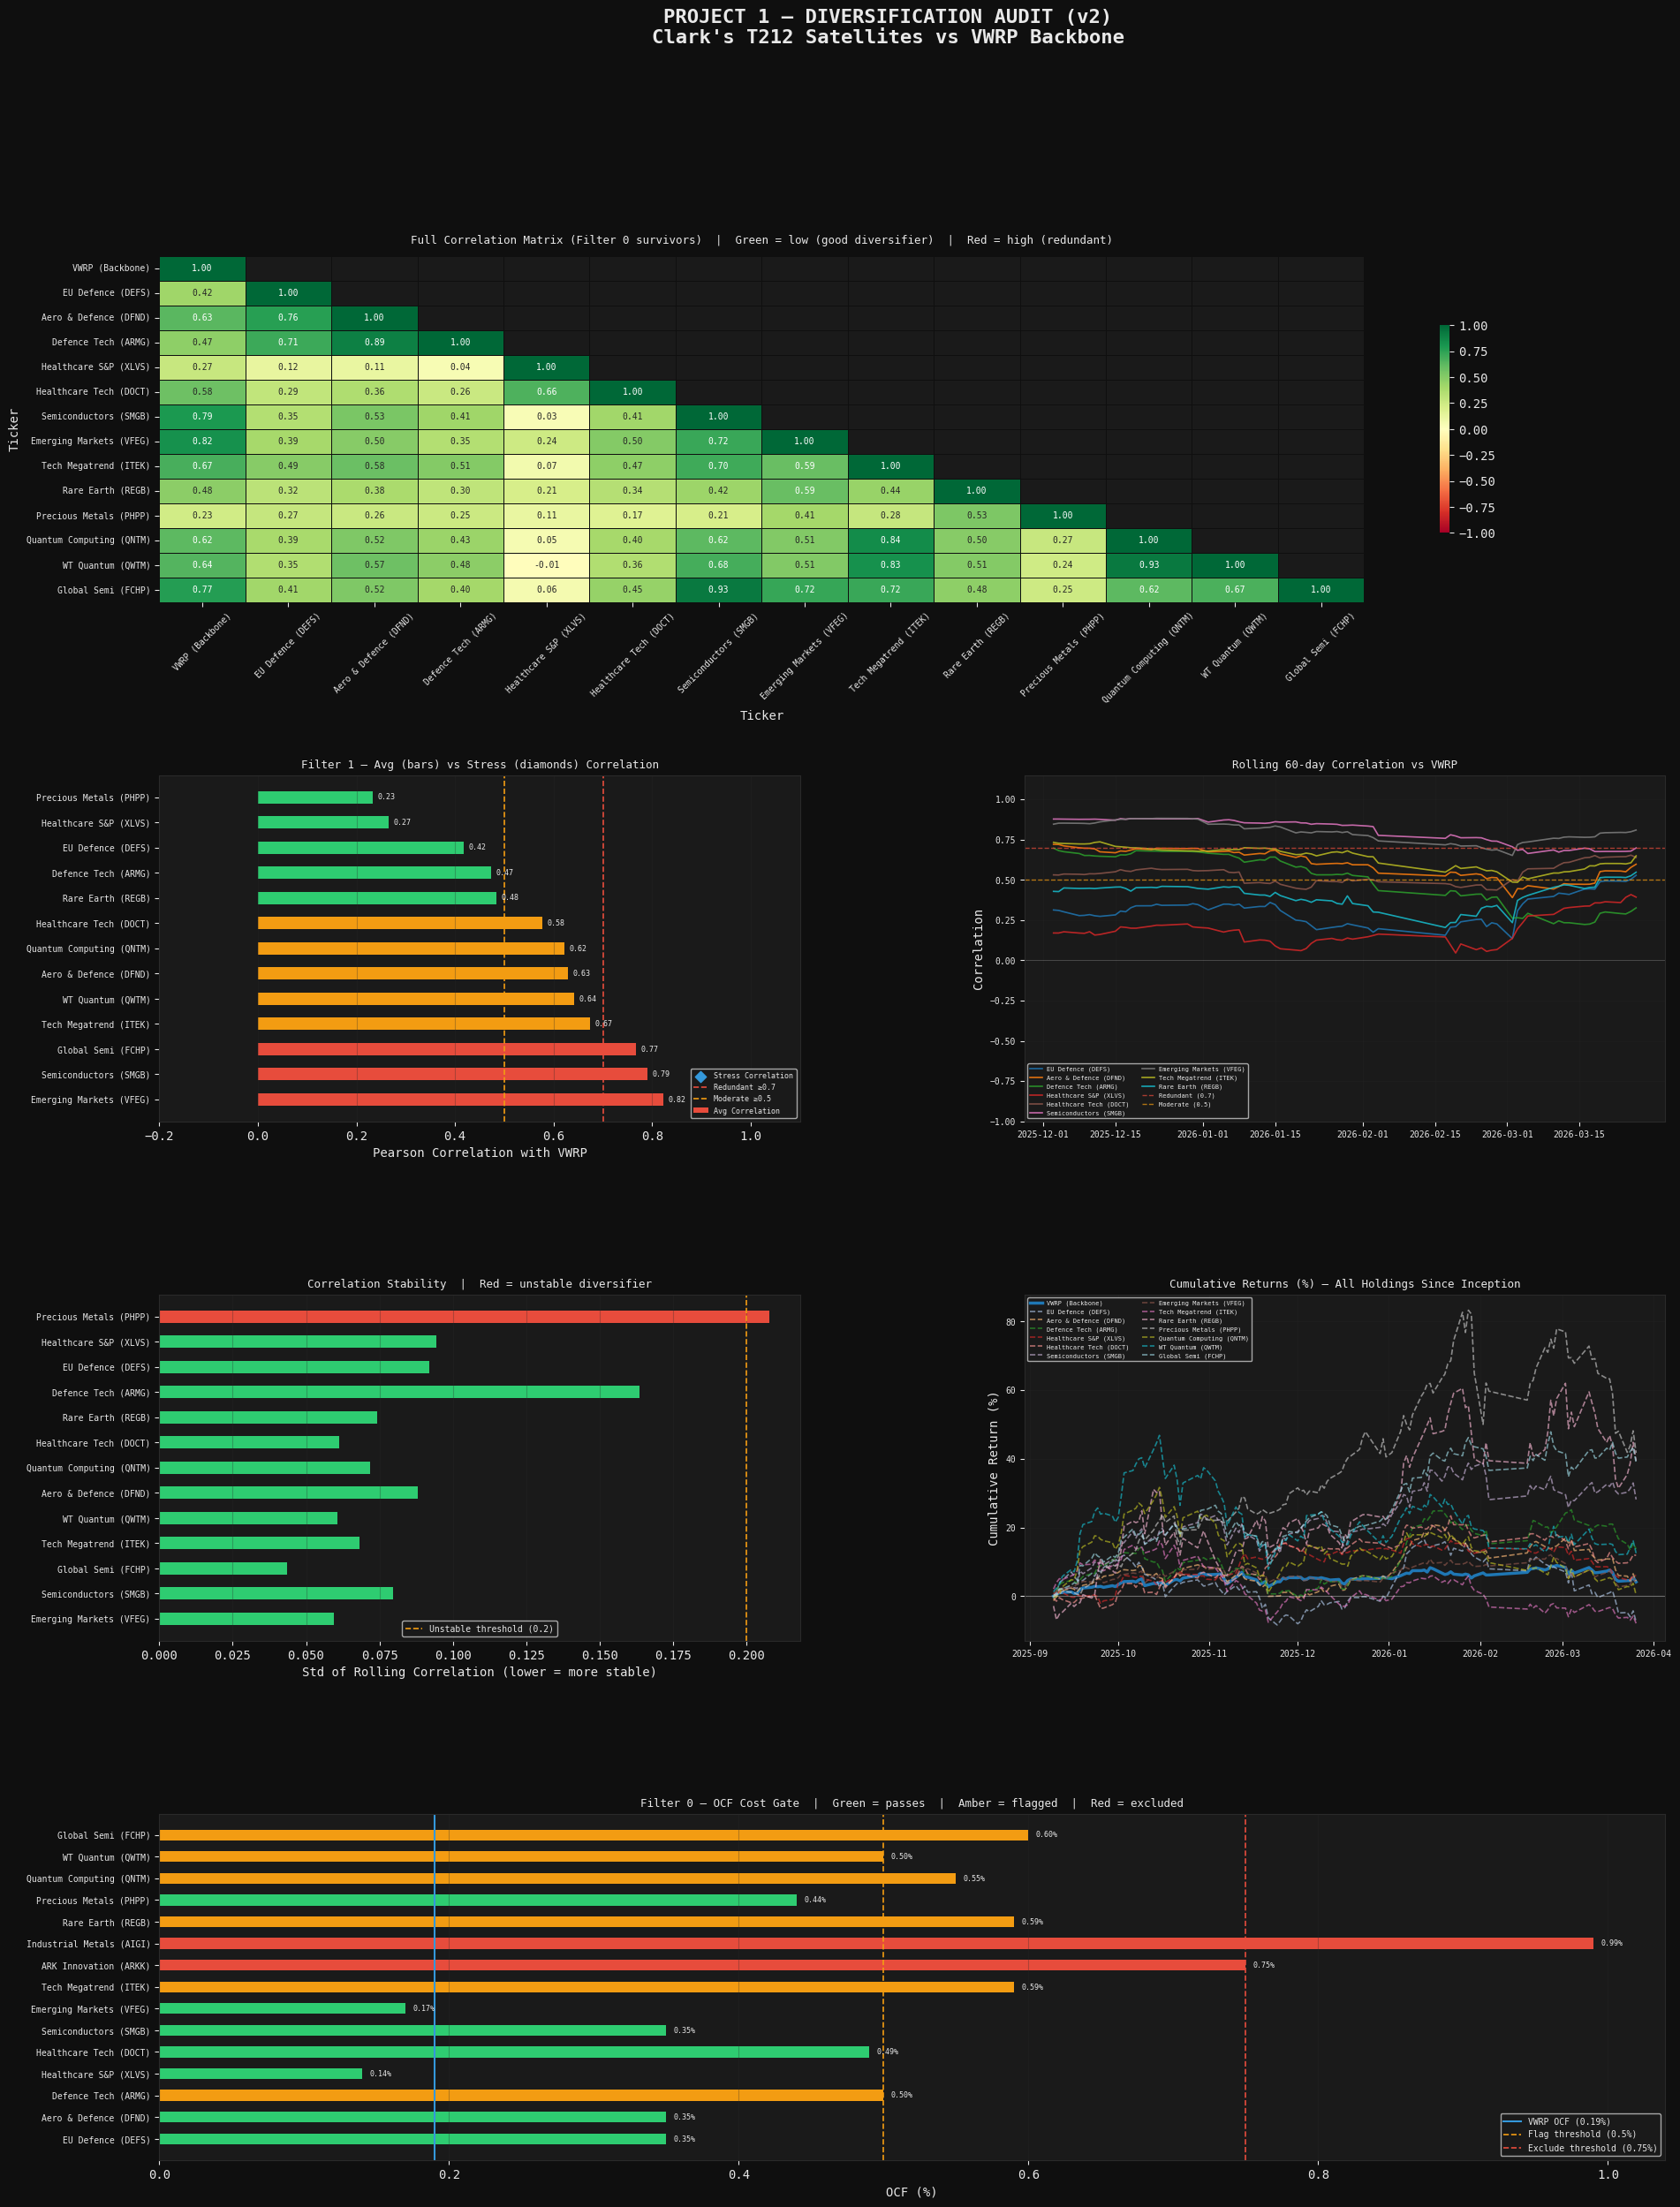

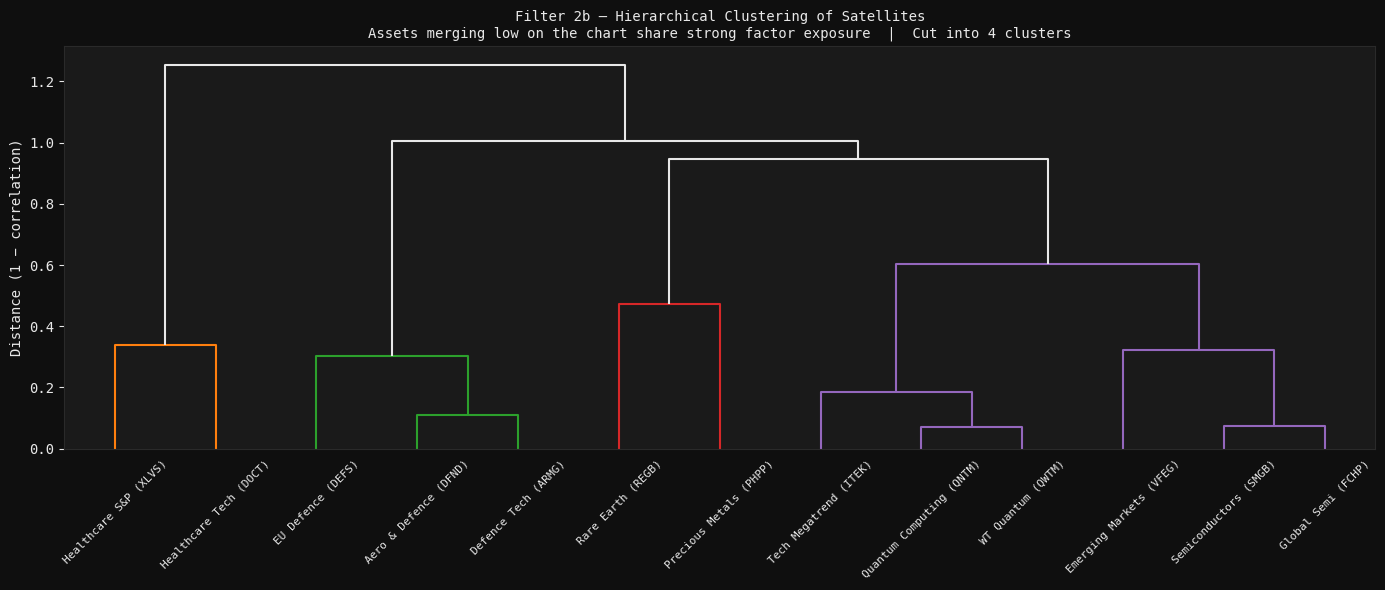


╔══════════════════════════════════════════════════════════════╗
║  PROJECT 1 COMPLETE — HANDOFF TO PROJECT 2                   ║
╠══════════════════════════════════════════════════════════════╣
║  Take the following into Filter 2a (Project 2):              ║
║                                                              ║
║  → Filter 0 survivors (OCF < 0.75%)                         ║
║  → Filter 1 survivors (not redundant on avg OR stress corr)  ║
║  → One representative per cluster from Filter 2b             ║
║                                                              ║
║  Project 2 will score each survivor on:                      ║
║    CAGR, Max Drawdown, Sharpe Ratio, CVaR                    ║
║                                                              ║
║  The weakest performers get cut there.                       ║
║  The survivors go to Project 3: Position Sizing.             ║
╚══════════════════════════════════════════════════════════════╝



In [4]:
"""
============================================================
 PROJECT 1 — DIVERSIFICATION AUDIT (v2)
 Clark's T212 Satellite Portfolio vs VWRP Backbone
============================================================

PIPELINE:
  Filter 0  → Cost Gate (OCF + premium vs VWRP)
  Filter 1  → Diversification vs VWRP
                - Average correlation
                - Correlation stability (rolling std)
                - Stress-period correlation (honest version)
  Filter 2b → Cross-correlation cluster analysis
                - Hierarchical clustering
                - Dendrogram visualisation

WHAT YOU'LL LEARN RUNNING THIS:
  - Which satellites are too expensive to justify
  - Which genuinely diversify vs which just look like they do
  - Which satellites are secretly the same bet
  - Which cluster representatives are worth taking to Project 2

KEY CONCEPTS:
  Pearson Correlation    → linear relationship between return series
  Rolling Correlation    → how that relationship changes over time
  Stress Correlation     → correlation ONLY during VWRP drawdowns
                           (the honest metric — diversification when
                           you actually need it)
  Correlation Stability  → std of rolling correlation series
                           (low = reliable, high = regime-dependent)
  Hierarchical Clustering → grouping assets by shared factor exposure
                            using distance = 1 - correlation
============================================================
"""

# ── IMPORTS ──────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')


# ══════════════════════════════════════════════════════════
#  CONFIGURATION — edit this section to update holdings
# ══════════════════════════════════════════════════════════

# London-listed ETFs use the .L suffix on Yahoo Finance.
HOLDINGS = {
    'VWRP.L':  'VWRP (Backbone)',
    'DEFS.L':  'EU Defence (DEFS)',
    'DFND.L':  'Aero & Defence (DFND)',
    'ARMG.L':  'Defence Tech (ARMG)',
    'XLVS.L':  'Healthcare S&P (XLVS)',
    'DOCT.L':  'Healthcare Tech (DOCT)',
    'SMGB.L':  'Semiconductors (SMGB)',
    'VFEG.L':  'Emerging Markets (VFEG)',
    'ITEK.L':  'Tech Megatrend (ITEK)',
    'ARKK.L':  'ARK Innovation (ARKK)',
    'AIGI.L':  'Industrial Metals (AIGI)',
    'REGB.L':  'Rare Earth (REGB)',
    'PHPP.L':  'Precious Metals (PHPP)',
    'QNTM.L':  'Quantum Computing (QNTM)',
    'QWTM.L':  'WT Quantum (QWTM)',
    'FCHP.L':  'Global Semi (FCHP)',
}

# OCF (Ongoing Charge Figure) — verify these on each
# provider's website / KIID document before running.
# These are your best estimates as of March 2026.
OCF_DATA = {
    'VWRP.L':  0.19,
    'DEFS.L':  0.35,
    'DFND.L':  0.35,
    'ARMG.L':  0.50,
    'XLVS.L':  0.14,
    'DOCT.L':  0.49,
    'SMGB.L':  0.35,
    'VFEG.L':  0.17,
    'ITEK.L':  0.59,
    'ARKK.L':  0.75,
    'AIGI.L':  0.99,
    'REGB.L':  0.59,
    'PHPP.L':  0.44,
    'QNTM.L':  0.55,
    'QWTM.L':  0.50,
    'FCHP.L':  0.60,
}

BACKBONE   = 'VWRP.L'
START_DATE = '2022-01-01'   # Captures a full market cycle including 2022 drawdown
END_DATE   = '2026-03-27'

# ── Thresholds ────────────────────────────────────────────
OCF_EXCLUDE       = 0.75   # Hard ceiling — excluded from all further filters
OCF_FLAG          = 0.50   # Above this → flagged, needs strong case in Filter 2a

CORR_WINDOW       = 60     # Rolling window in trading days (~3 months)
HIGH_CORR         = 0.70   # Above this → redundant vs VWRP
MEDIUM_CORR       = 0.50   # Between 0.5–0.7 → moderate overlap

STRESS_HIGH       = 0.80   # Stress correlation above this → redundant under pressure
STRESS_MEDIUM     = 0.65   # Stress correlation above this → moderate under pressure
STABILITY_FLAG    = 0.20   # Rolling corr std above this → unstable diversifier

DRAWDOWN_THRESHOLD = -0.01  # VWRP daily return below this defines a "stress day"
                             # i.e. days VWRP fell more than 1%

HIGH_CROSS_CORR   = 0.75   # Cross-correlation above this → same bet
N_CLUSTERS        = 4      # Number of clusters for hierarchical analysis
                            # Adjust after inspecting the dendrogram


# ── STYLE ─────────────────────────────────────────────────
PALETTE = {
    'background': '#0f0f0f',
    'panel':      '#1a1a1a',
    'text':       '#e8e8e8',
    'green':      '#2ecc71',
    'amber':      '#f39c12',
    'red':        '#e74c3c',
    'blue':       '#3498db',
    'grid':       '#2a2a2a',
}

plt.rcParams.update({
    'figure.facecolor': PALETTE['background'],
    'axes.facecolor':   PALETTE['panel'],
    'axes.edgecolor':   PALETTE['grid'],
    'axes.labelcolor':  PALETTE['text'],
    'xtick.color':      PALETTE['text'],
    'ytick.color':      PALETTE['text'],
    'text.color':       PALETTE['text'],
    'grid.color':       PALETTE['grid'],
    'font.family':      'monospace',
})


# ══════════════════════════════════════════════════════════
#  STEP 1 — DOWNLOAD PRICE DATA
# ══════════════════════════════════════════════════════════

print("\n📥 Downloading price data from Yahoo Finance...")
print(f"   Period: {START_DATE} → {END_DATE}\n")

tickers = list(HOLDINGS.keys())
raw = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)['Close']

if isinstance(raw, pd.Series):
    raw = raw.to_frame()

available = [t for t in tickers
             if t in raw.columns and raw[t].notna().sum() > 30]
missing   = [t for t in tickers if t not in available]

if missing:
    print(f"⚠️  Could not retrieve data for: {missing}")
    print("   These will be excluded. Check tickers on finance.yahoo.com\n")

prices = raw[available].dropna(how='all')
print(f"✅ Retrieved {len(available)} tickers.")
print(f"   Date range: {prices.index[0].date()} → {prices.index[-1].date()}\n")

# Rename to short names for readability throughout
short_names   = {t: HOLDINGS[t] for t in available if t in HOLDINGS}
prices.rename(columns=short_names, inplace=True)
backbone_name = HOLDINGS[BACKBONE]


# ══════════════════════════════════════════════════════════
#  STEP 2 — COMPUTE RETURNS
# ══════════════════════════════════════════════════════════
# WHY returns not prices?
# Price levels are non-stationary — they trend upward over time.
# Correlation requires stationary inputs. Daily percentage
# returns satisfy this requirement.
# pct_change() = (P_t - P_{t-1}) / P_{t-1}

returns = prices.pct_change().dropna()


# ══════════════════════════════════════════════════════════
#  FILTER 0 — COST GATE
# ══════════════════════════════════════════════════════════
# WHY this runs first:
# Every basis point of OCF above VWRP is a guaranteed
# performance hurdle the satellite must clear before adding
# any value. Making this explicit prevents optimising a
# portfolio that's structurally expensive.
#
# COMPOUNDING DRAG: a 0.5% annual OCF difference on £500
# over 10 years at 8% gross return costs roughly £40–50
# in compounded returns. Small numbers, real money.

print("=" * 75)
print("  FILTER 0 — COST GATE")
print("  Threshold: OCF ≥ 0.75% → excluded | ≥ 0.50% → flagged")
print("=" * 75)
print(f"  {'ETF':<35} {'OCF':>6}   {'vs VWRP':>8}   Verdict")
print("-" * 75)

backbone_ocf  = OCF_DATA.get(BACKBONE, 0.22)
filter0_pass  = []   # Tickers (short names) that pass to Filter 1
filter0_fail  = []

for ticker in available:
    name = HOLDINGS[ticker]
    if ticker == BACKBONE:
        continue
    ocf = OCF_DATA.get(ticker, None)
    if ocf is None:
        print(f"  {name:<35} {'N/A':>6}   {'N/A':>8}   ⚠️  No OCF data — exclude manually")
        continue
    premium = ocf - backbone_ocf
    if ocf >= OCF_EXCLUDE:
        verdict = '❌ Excluded — cost too high'
        filter0_fail.append(name)
    elif ocf >= OCF_FLAG:
        verdict = '⚠️  Flagged — needs strong Filter 1+2a case'
        filter0_pass.append(name)
    else:
        verdict = '✅ Passes'
        filter0_pass.append(name)
    print(f"  {name:<35} {ocf:>5.2f}%   {premium:>+7.2f}%   {verdict}")

print("=" * 75)
print(f"\n  ✅ {len(filter0_pass)} holdings pass to Filter 1.")
if filter0_fail:
    print(f"  ❌ {len(filter0_fail)} excluded: {filter0_fail}\n")

# Remove failed holdings from returns for all downstream analysis
satellite_names = [n for n in returns.columns
                   if n != backbone_name and n not in filter0_fail]
analysis_cols   = [backbone_name] + satellite_names
returns_filtered = returns[
    [c for c in analysis_cols if c in returns.columns]
]


# ══════════════════════════════════════════════════════════
#  STEP 3 — CORRELATION MATRIX (on Filter 0 survivors)
# ══════════════════════════════════════════════════════════
# R[i,j] = cov(i,j) / (std(i) * std(j))
# Normalised covariance matrix. Values in [-1, 1].

corr_matrix  = returns_filtered.corr()
corr_vs_vwrp = (corr_matrix[backbone_name]
                .drop(backbone_name)
                .sort_values(ascending=False))


# ══════════════════════════════════════════════════════════
#  STEP 4 — ROLLING CORRELATION
# ══════════════════════════════════════════════════════════
# Static correlation hides regime changes.
# Rolling correlation reveals how the relationship evolves —
# and critically, whether it spikes during drawdowns.
# std of the rolling series measures stability.

rolling_corr = (
    returns_filtered
    .drop(columns=[backbone_name])
    .rolling(CORR_WINDOW)
    .corr(returns_filtered[backbone_name])
    .dropna()
)

rolling_corr_std = rolling_corr.std()


# ══════════════════════════════════════════════════════════
#  STEP 5 — STRESS-PERIOD CORRELATION
# ══════════════════════════════════════════════════════════
# The honest version of Filter 1.
#
# Average correlation averages calm and volatile periods
# together — which flatters the diversification picture.
#
# Stress correlation isolates only the days when VWRP
# was actually falling (below DRAWDOWN_THRESHOLD).
# This answers: "does this satellite protect me when I
# need protection, or does it just behave independently
# on quiet days?"
#
# Correlation convergence under stress is one of the most
# dangerous properties a satellite can have — it means
# the diversification benefit disappears precisely when
# the portfolio is under pressure.

vwrp_returns   = returns_filtered[backbone_name]
drawdown_mask  = vwrp_returns < DRAWDOWN_THRESHOLD
drawdown_days  = returns_filtered[drawdown_mask]

stress_corr = {}
for col in satellite_names:
    if col not in drawdown_days.columns:
        continue
    n_obs = drawdown_days[[col, backbone_name]].dropna().shape[0]
    if n_obs > 10:
        stress_corr[col] = (
            drawdown_days[col]
            .corr(drawdown_days[backbone_name])
        )
    else:
        stress_corr[col] = np.nan   # Insufficient stress observations

stress_corr_series = pd.Series(stress_corr)


# ══════════════════════════════════════════════════════════
#  FILTER 1 — VERDICT TABLE (extended)
# ══════════════════════════════════════════════════════════

def filter1_verdict(avg_c, stress_c):
    """
    Verdict uses BOTH average and stress correlation.
    A satellite can fail Filter 1 on stress correlation alone
    even if its average correlation looks acceptable.
    """
    stress_c = stress_c if not np.isnan(stress_c) else avg_c
    if avg_c >= HIGH_CORR or stress_c >= STRESS_HIGH:
        return '❌ Redundant'
    elif avg_c >= MEDIUM_CORR or stress_c >= STRESS_MEDIUM:
        return '⚠️  Moderate overlap'
    else:
        return '✅ Good diversifier'

def stability_verdict(std_c):
    if np.isnan(std_c):
        return '❓ Unknown'
    return '⚠️  Unstable' if std_c > STABILITY_FLAG else '✅ Stable'

print("\n" + "=" * 100)
print("  FILTER 1 — DIVERSIFICATION VERDICT vs VWRP")
print(f"  Stress days: VWRP daily return < {DRAWDOWN_THRESHOLD*100:.0f}%  |  "
      f"Stability: rolling corr std > {STABILITY_FLAG} = unstable")
print("=" * 100)
print(f"  {'ETF':<30} {'Avg Corr':>9} {'Stress Corr':>12} {'Corr Std':>9}   "
      f"{'Verdict':<25} Stability")
print("-" * 100)

filter1_pass = []
filter1_fail = []

for etf in corr_vs_vwrp.index:
    avg_c    = corr_vs_vwrp[etf]
    stress_c = stress_corr_series.get(etf, np.nan)
    std_c    = rolling_corr_std.get(etf, np.nan)
    verdict  = filter1_verdict(avg_c, stress_c)
    stab     = stability_verdict(std_c)

    stress_str = f"{stress_c:.3f}" if not np.isnan(stress_c) else "  N/A"
    std_str    = f"{std_c:.3f}"    if not np.isnan(std_c)    else " N/A"

    print(f"  {etf:<30} {avg_c:>9.3f} {stress_str:>12} {std_str:>9}   "
          f"{verdict:<25} {stab}")

    if '❌' in verdict:
        filter1_fail.append(etf)
    else:
        filter1_pass.append(etf)

print("=" * 100)
print(f"\n  ✅ {len(filter1_pass)} holdings pass to Filter 2.")
print(f"  ❌ {len(filter1_fail)} filtered out: {filter1_fail}\n")


# ══════════════════════════════════════════════════════════
#  STEP 6 — CUMULATIVE RETURNS
# ══════════════════════════════════════════════════════════
# (1 + r).cumprod() - 1 compounds daily returns.
# Geometric compounding — reflects actual portfolio growth.

cum_returns = (1 + returns_filtered).cumprod() - 1


# ══════════════════════════════════════════════════════════
#  FILTER 2b — CLUSTER ANALYSIS
# ══════════════════════════════════════════════════════════
# WHY cluster analysis rather than just flagging pairs?
#
# Flagging pairs tells you "these two are similar."
# Cluster analysis tells you "here are your distinct
# factor exposure groups — keep one representative each."
#
# METHOD: Hierarchical clustering using Ward's linkage.
#
# DISTANCE MATRIX: distance = 1 - correlation
#   → perfectly correlated assets (ρ=1) → distance 0
#   → uncorrelated (ρ=0)               → distance 1
#   → perfectly inverse (ρ=-1)         → distance 2
#
# WARD'S LINKAGE: merges clusters that minimise the
# increase in total within-cluster variance. This tends
# to produce compact, well-separated clusters — appropriate
# for identifying distinct factor exposure groups.
#
# DENDROGRAM: the visual output. Assets that merge low
# on the chart share strong factor exposure. Assets that
# only merge near the top are genuinely distinct.

sat_names_f2 = [c for c in corr_matrix.columns
                if c != backbone_name]

if len(sat_names_f2) >= 2:
    sat_corr_mat = corr_matrix.loc[sat_names_f2, sat_names_f2]
    distance_mat = 1 - sat_corr_mat

    # Enforce symmetry and non-negativity
    # (floating point arithmetic can introduce tiny violations)
    # .copy() is required here — newer numpy returns a read-only
    # view from .values, so we need an explicit writable copy
    # before fill_diagonal can mutate the diagonal in place.
    distance_mat = (distance_mat + distance_mat.T) / 2
    dist_array   = distance_mat.values.copy()        # ← writable copy
    np.fill_diagonal(dist_array, 0)
    distance_mat = pd.DataFrame(
        dist_array,
        index=distance_mat.index,
        columns=distance_mat.columns
    ).clip(lower=0)

    condensed   = squareform(distance_mat.values)
    linkage_mat = linkage(condensed, method='ward')

    n_clusters_actual = min(N_CLUSTERS, len(sat_names_f2))
    cluster_labels    = fcluster(
        linkage_mat, n_clusters_actual, criterion='maxclust'
    )

    cluster_df = pd.DataFrame({
        'ETF':     sat_names_f2,
        'Cluster': cluster_labels
    }).sort_values('Cluster')

    print("=" * 75)
    print("  FILTER 2b — CLUSTER ANALYSIS")
    print("  Assets in the same cluster share factor exposure.")
    print("  → Keep only the strongest representative per cluster.")
    print("=" * 75)

    for cluster_id in sorted(cluster_df['Cluster'].unique()):
        members = cluster_df[
            cluster_df['Cluster'] == cluster_id
        ]['ETF'].tolist()
        print(f"\n  Cluster {cluster_id}  ({len(members)} member{'s' if len(members)>1 else ''}):")
        for m in members:
            avg_c    = corr_vs_vwrp.get(m, np.nan)
            stress_c = stress_corr_series.get(m, np.nan)
            f0_flag  = '⚠️ flagged' if m in [
                HOLDINGS[t] for t in available
                if OCF_DATA.get(t, 0) >= OCF_FLAG
                and OCF_DATA.get(t, 0) < OCF_EXCLUDE
            ] else ''
            avg_str    = f"{avg_c:.3f}"    if not np.isnan(avg_c)    else "N/A"
            stress_str = f"{stress_c:.3f}" if not np.isnan(stress_c) else "N/A"
            print(f"    → {m:<35} avg corr: {avg_str}  stress corr: {stress_str}  {f0_flag}")
        if len(members) > 1:
            print(f"  ⚠️  Multiple members — take only the best to Filter 2a.")

    print("\n" + "=" * 75)

    # ── Legacy pair-flag output (kept for reference) ──────
    print("\n  HIGH CROSS-CORRELATION PAIRS (ρ ≥ {:.2f}):".format(HIGH_CROSS_CORR))
    pairs = []
    for i in range(len(sat_names_f2)):
        for j in range(i + 1, len(sat_names_f2)):
            c = sat_corr_mat.iloc[i, j]
            if c >= HIGH_CROSS_CORR:
                pairs.append((sat_names_f2[i], sat_names_f2[j], c))
    pairs.sort(key=lambda x: -x[2])
    if pairs:
        for a, b, c in pairs:
            print(f"  ⚠️  {a:<30} ↔  {b:<30} ({c:.2f})")
    else:
        print("  ✅ No pairs above threshold.")
    print("=" * 75)

else:
    print("⚠️  Fewer than 2 satellites available for cluster analysis.")
    linkage_mat  = None
    sat_names_f2 = []


# ══════════════════════════════════════════════════════════
#  VISUALISATION
# ══════════════════════════════════════════════════════════

# ── Figure 1: Main Audit Dashboard ───────────────────────
fig1 = plt.figure(figsize=(22, 28))
fig1.suptitle(
    "PROJECT 1 — DIVERSIFICATION AUDIT (v2)\n"
    "Clark's T212 Satellites vs VWRP Backbone",
    fontsize=16, fontweight='bold',
    color=PALETTE['text'], y=0.98
)
gs = gridspec.GridSpec(4, 2, figure=fig1, hspace=0.50, wspace=0.35)


# Chart 1: Full Correlation Heatmap
ax1 = fig1.add_subplot(gs[0, :])
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor=PALETTE['background'],
    annot_kws={'size': 7},
    ax=ax1,
    cbar_kws={'shrink': 0.6}
)
ax1.set_title(
    'Full Correlation Matrix (Filter 0 survivors)  |  '
    'Green = low (good diversifier)  |  Red = high (redundant)',
    fontsize=9, pad=10
)
ax1.tick_params(axis='x', rotation=45, labelsize=7)
ax1.tick_params(axis='y', rotation=0,  labelsize=7)


# Chart 2: Average + Stress Correlation vs VWRP
ax2 = fig1.add_subplot(gs[1, 0])

avg_vals    = corr_vs_vwrp.values
etf_labels  = list(corr_vs_vwrp.index)
stress_vals = [stress_corr_series.get(e, np.nan) for e in etf_labels]
y_pos       = np.arange(len(etf_labels))

avg_colours = [
    PALETTE['red']   if c >= HIGH_CORR   else
    PALETTE['amber'] if c >= MEDIUM_CORR else
    PALETTE['green']
    for c in avg_vals
]

bars = ax2.barh(y_pos, avg_vals, color=avg_colours,
                edgecolor='none', height=0.5, label='Avg Correlation')

# Overlay stress correlation as scatter dots
stress_plot = [v for v in stress_vals]
ax2.scatter(
    stress_plot, y_pos,
    color=PALETTE['blue'], zorder=5, s=40,
    label='Stress Correlation', marker='D'
)

ax2.axvline(HIGH_CORR,   color=PALETTE['red'],   ls='--', lw=1.2,
            label=f'Redundant ≥{HIGH_CORR}')
ax2.axvline(MEDIUM_CORR, color=PALETTE['amber'], ls='--', lw=1.2,
            label=f'Moderate ≥{MEDIUM_CORR}')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(etf_labels, fontsize=7)
ax2.set_xlabel('Pearson Correlation with VWRP')
ax2.set_title(
    'Filter 1 — Avg (bars) vs Stress (diamonds) Correlation',
    fontsize=9
)
ax2.legend(fontsize=6, loc='lower right')
ax2.set_xlim(-0.2, 1.1)
ax2.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, avg_vals):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=6,
             color=PALETTE['text'])


# Chart 3: Rolling Correlation vs VWRP
ax3 = fig1.add_subplot(gs[1, 1])
sat_plot_cols = [c for c in rolling_corr.columns][:9]
cmap_lines    = plt.cm.tab10(np.linspace(0, 1, len(sat_plot_cols)))

for col, colour in zip(sat_plot_cols, cmap_lines):
    if col in rolling_corr.columns:
        ax3.plot(
            rolling_corr.index,
            rolling_corr[col],
            label=col, lw=1.2, color=colour, alpha=0.85
        )

ax3.axhline(HIGH_CORR,   color=PALETTE['red'],   ls='--', lw=1, alpha=0.7,
            label=f'Redundant ({HIGH_CORR})')
ax3.axhline(MEDIUM_CORR, color=PALETTE['amber'], ls='--', lw=1, alpha=0.7,
            label=f'Moderate ({MEDIUM_CORR})')
ax3.axhline(0, color=PALETTE['text'], lw=0.5, alpha=0.3)
ax3.set_title(f'Rolling {CORR_WINDOW}-day Correlation vs VWRP', fontsize=9)
ax3.set_ylabel('Correlation')
ax3.set_ylim(-1, 1.15)
ax3.legend(fontsize=5, loc='lower left', ncol=2)
ax3.grid(alpha=0.2)
ax3.tick_params(labelsize=7)


# Chart 4: Correlation Stability (rolling std)
ax4 = fig1.add_subplot(gs[2, 0])

stab_vals   = [rolling_corr_std.get(e, np.nan) for e in etf_labels]
stab_colours = [
    PALETTE['red'] if v > STABILITY_FLAG else PALETTE['green']
    for v in stab_vals
]
ax4.barh(y_pos, stab_vals, color=stab_colours,
         edgecolor='none', height=0.5)
ax4.axvline(STABILITY_FLAG, color=PALETTE['amber'], ls='--', lw=1.2,
            label=f'Unstable threshold ({STABILITY_FLAG})')
ax4.set_yticks(y_pos)
ax4.set_yticklabels(etf_labels, fontsize=7)
ax4.set_xlabel('Std of Rolling Correlation (lower = more stable)')
ax4.set_title(
    'Correlation Stability  |  Red = unstable diversifier',
    fontsize=9
)
ax4.legend(fontsize=7)
ax4.grid(axis='x', alpha=0.3)


# Chart 5: Cumulative Returns
ax5 = fig1.add_subplot(gs[2, 1])
cmap_ret = plt.cm.tab20(np.linspace(0, 1, len(cum_returns.columns)))
for col, colour in zip(cum_returns.columns, cmap_ret):
    lw    = 2.5 if col == backbone_name else 1.2
    alpha = 1.0 if col == backbone_name else 0.65
    ls    = '-'  if col == backbone_name else '--'
    ax5.plot(
        cum_returns.index,
        cum_returns[col] * 100,
        label=col, lw=lw, color=colour, alpha=alpha, ls=ls
    )
ax5.axhline(0, color=PALETTE['text'], lw=0.8, alpha=0.4)
ax5.set_title('Cumulative Returns (%) — All Holdings Since Inception', fontsize=9)
ax5.set_ylabel('Cumulative Return (%)')
ax5.legend(fontsize=5, ncol=2, loc='upper left')
ax5.grid(alpha=0.2)
ax5.tick_params(labelsize=7)


# Chart 6: OCF Cost Chart (Filter 0 visual)
ax6 = fig1.add_subplot(gs[3, :])
all_names = [HOLDINGS[t] for t in available if t in HOLDINGS and t != BACKBONE]
all_ocfs  = [OCF_DATA.get(t, np.nan) for t in available if t in HOLDINGS and t != BACKBONE]
ocf_colours = [
    PALETTE['red']   if v >= OCF_EXCLUDE else
    PALETTE['amber'] if v >= OCF_FLAG    else
    PALETTE['green']
    for v in all_ocfs
]
y_ocf = np.arange(len(all_names))
ax6.barh(y_ocf, all_ocfs, color=ocf_colours, edgecolor='none', height=0.5)
ax6.axvline(backbone_ocf, color=PALETTE['blue'], ls='-',  lw=1.5,
            label=f'VWRP OCF ({backbone_ocf}%)')
ax6.axvline(OCF_FLAG,     color=PALETTE['amber'], ls='--', lw=1.2,
            label=f'Flag threshold ({OCF_FLAG}%)')
ax6.axvline(OCF_EXCLUDE,  color=PALETTE['red'],   ls='--', lw=1.2,
            label=f'Exclude threshold ({OCF_EXCLUDE}%)')
ax6.set_yticks(y_ocf)
ax6.set_yticklabels(all_names, fontsize=7)
ax6.set_xlabel('OCF (%)')
ax6.set_title('Filter 0 — OCF Cost Gate  |  Green = passes  |  Amber = flagged  |  Red = excluded', fontsize=9)
ax6.legend(fontsize=7, loc='lower right')
ax6.grid(axis='x', alpha=0.3)
for i, val in enumerate(all_ocfs):
    if not np.isnan(val):
        ax6.text(val + 0.005, i, f'{val:.2f}%', va='center',
                 fontsize=6, color=PALETTE['text'])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


# ── Figure 2: Dendrogram ──────────────────────────────────
if linkage_mat is not None and len(sat_names_f2) >= 2:
    fig2, ax_d = plt.subplots(
        figsize=(14, 6),
        facecolor=PALETTE['background']
    )
    ax_d.set_facecolor(PALETTE['panel'])

    dendrogram(
        linkage_mat,
        labels=sat_names_f2,
        ax=ax_d,
        color_threshold=0.7 * max(linkage_mat[:, 2]),
        above_threshold_color=PALETTE['text'],
        leaf_rotation=45,
        leaf_font_size=8,
    )
    ax_d.set_title(
        'Filter 2b — Hierarchical Clustering of Satellites\n'
        'Assets merging low on the chart share strong factor exposure  |  '
        f'Cut into {N_CLUSTERS} clusters',
        fontsize=10, color=PALETTE['text']
    )
    ax_d.tick_params(colors=PALETTE['text'])
    ax_d.spines['bottom'].set_color(PALETTE['grid'])
    ax_d.spines['left'].set_color(PALETTE['grid'])
    ax_d.set_ylabel('Distance (1 − correlation)', color=PALETTE['text'])
    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════
#  SUMMARY — WHAT TO TAKE INTO PROJECT 2
# ══════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════╗
║  PROJECT 1 COMPLETE — HANDOFF TO PROJECT 2                   ║
╠══════════════════════════════════════════════════════════════╣
║  Take the following into Filter 2a (Project 2):              ║
║                                                              ║
║  → Filter 0 survivors (OCF < 0.75%)                         ║
║  → Filter 1 survivors (not redundant on avg OR stress corr)  ║
║  → One representative per cluster from Filter 2b             ║
║                                                              ║
║  Project 2 will score each survivor on:                      ║
║    CAGR, Max Drawdown, Sharpe Ratio, CVaR                    ║
║                                                              ║
║  The weakest performers get cut there.                       ║
║  The survivors go to Project 3: Position Sizing.             ║
╚══════════════════════════════════════════════════════════════╝
""")